# Practical Session 02a &mdash; The linear model & the least-squares cost

**Companion to Lecture&nbsp;02 (Linear Regression).** This is the first of four practical
notebooks that build linear regression **entirely from scratch in NumPy** and check every step
against scikit-learn:

| # | Notebook | Topic |
|---|----------|-------|
| **02a** | **model & cost** | **the line, residuals, the least-squares cost, the "bowl" (this notebook)** |
| 02b | closed form | the normal equations & the column-space geometry, from scratch |
| 02c | gradient descent | batch / stochastic / mini-batch GD, learning rate, feature scaling |
| 02d | evaluation & complexity | metrics from scratch, polynomial features, overfitting, real data |

Linear regression predicts a **number** (a *continuous* target) as a straight-line function of
the inputs. Before we can *fit* it, we need two things: a **model** (the family of lines we are
allowed to pick from) and a **cost** (a score that says how good a given line is). This notebook
nails both, and draws the picture the whole method rests on: the cost **bowl**.

> ⭐ **Key idea.** Fitting a model = choosing its parameters to **minimize a cost**. For linear
> regression the cost is the **mean squared error**, and as a function of the parameters it is a
> smooth, convex **bowl** with a single lowest point &mdash; the best-fit line.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style          # local styling helper (sibling file)
from nb_data import make_regression_1d  # local synthetic data (sibling file)

use_style("notes")
print("ready")

ready


## 1. The model: a line with two knobs

For one input feature $x$, the linear model predicts

$$\hat y = h_{\mathbf{w}}(x) = w_0 + w_1\,x,$$

with two parameters: the **intercept** $w_0$ (where the line crosses $x=0$) and the **slope**
$w_1$ (how fast $\hat y$ rises with $x$). Different $(w_0, w_1)$ give different lines; *fitting*
means choosing the pair that best matches the data.

x: (40,) | y: (40,)


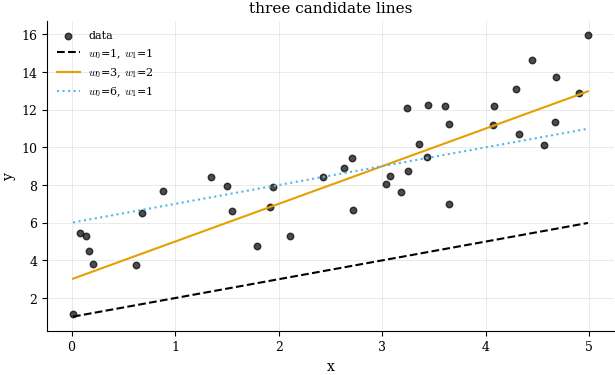

In [2]:
x, y = make_regression_1d(n=40, seed=0)   # noisy line: true intercept 3.0, slope 2.0
print("x:", x.shape, "| y:", y.shape)

def predict(x, w0, w1):
    return w0 + w1 * x

xs = np.linspace(x.min(), x.max(), 100)
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.scatter(x, y, s=22, alpha=0.7, label="data")
for w0, w1, style in [(1, 1, "--"), (3, 2, "-"), (6, 1, ":")]:
    ax.plot(xs, predict(xs, w0, w1), style, label=f"$w_0$={w0}, $w_1$={w1}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("three candidate lines"); ax.legend(fontsize=8)
plt.show()

Which line is best? Eyeballing is not enough &mdash; we need a **number** that scores each line.
That number comes from the *residuals*.

## 2. Residuals: how wrong each prediction is

For each point the **residual** is the vertical gap between the truth and the prediction,

$$r_i = y_i - \hat y_i = y_i - (w_0 + w_1 x_i).$$

Positive means the line is below the point, negative means above. A good line makes the
residuals small *overall*.

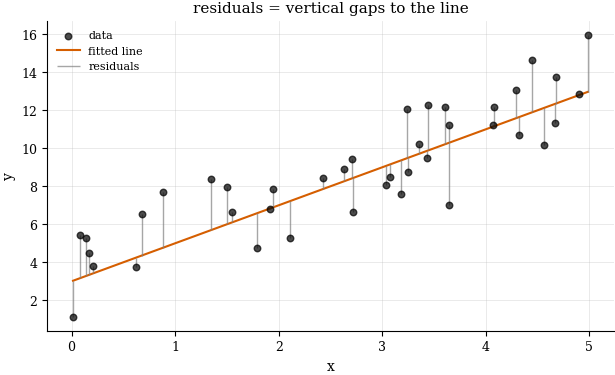

first 5 residuals: [-1.89  2.27  2.02  1.17  0.4 ]
sum of residuals : 18.068  (near 0 for a good intercept, but that alone is not enough)


In [3]:
w0, w1 = 3.0, 2.0
yhat = predict(x, w0, w1)
resid = y - yhat

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.scatter(x, y, s=22, alpha=0.7, zorder=3, label="data")
ax.plot(xs, predict(xs, w0, w1), color="#D55E00", label="fitted line")
ax.vlines(x, yhat, y, color="gray", lw=1, alpha=0.7, label="residuals")   # the vertical gaps
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("residuals = vertical gaps to the line")
ax.legend(fontsize=8)
plt.show()
print("first 5 residuals:", resid[:5].round(2))
print("sum of residuals :", resid.sum().round(3), " (near 0 for a good intercept, but that alone is not enough)")

> ⚠️ **Watch out.** We cannot just add the residuals: positives and negatives cancel, so a wild
> line can have sum-of-residuals zero. We need every error to count as *badness* regardless of
> sign. Two fixes: take the **absolute** value, or **square** it. Least-squares regression
> squares them &mdash; and Section&nbsp;3 (and 02b) explains why that particular choice is so nice.

## 3. The cost: mean squared error

Square each residual (so sign no longer matters and big misses hurt more), then average:

$$J(w_0, w_1) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - (w_0 + w_1 x_i)\big)^2 \quad\text{(MSE)}.$$

This is the **least-squares cost**. Fitting the model means finding the $(w_0, w_1)$ that make
$J$ as small as possible. Here it is, from scratch, in one vectorized line:

In [4]:
def cost(x, y, w0, w1):
    resid = y - (w0 + w1 * x)
    return np.mean(resid ** 2)          # mean squared error

for w0, w1 in [(1, 1), (3, 2), (6, 1)]:
    print(f"line (w0={w0}, w1={w1}):  MSE = {cost(x, y, w0, w1):7.2f}")

line (w0=1, w1=1):  MSE =   30.72
line (w0=3, w1=2):  MSE =    2.84
line (w0=6, w1=1):  MSE =    4.37


The middle line scores far lower &mdash; consistent with our eyes. The cost has turned "which line
looks better?" into a number we can *minimize*.

> 🔬 **Going deeper (why squares?).** Beyond convenience, squaring has a principled reading: if
> the data are a true line plus **Gaussian noise**, then the least-squares line is exactly the
> **maximum-likelihood** estimate. Squared error also makes $J$ smooth and *convex* &mdash; a single
> bowl with no false bottoms &mdash; which is what lets both the closed form (02b) and gradient
> descent (02c) work so cleanly. We derive the Gaussian connection in 02b.

## 4. The cost surface is a bowl

$J$ is a function of the two parameters, so we can plot it *over the parameter plane*
$(w_0, w_1)$. Evaluate it on a grid and look: it is a smooth, convex **bowl** with one lowest
point &mdash; and that point is the best-fit line.

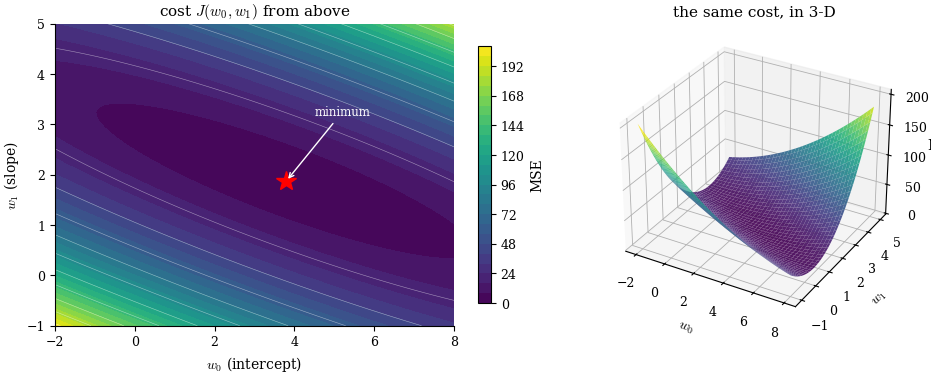

In [5]:
w0_grid = np.linspace(-2, 8, 120)
w1_grid = np.linspace(-1, 5, 120)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
J = np.array([[cost(x, y, a, b) for a in w0_grid] for b in w1_grid])

fig = plt.figure(figsize=(9.6, 3.8))
# (a) filled contours: the bowl seen from above
ax1 = fig.add_subplot(1, 2, 1)
cs = ax1.contourf(W0, W1, J, levels=25, cmap="viridis")
ax1.contour(W0, W1, J, levels=12, colors="white", linewidths=0.4, alpha=0.5)
imin = np.unravel_index(J.argmin(), J.shape)
ax1.plot(W0[imin], W1[imin], "r*", ms=15)
ax1.annotate("minimum", xy=(W0[imin], W1[imin]), xytext=(W0[imin] + 0.7, W1[imin] + 1.3),
             fontsize=8.5, color="white",
             arrowprops=dict(arrowstyle="->", color="white", lw=1))
ax1.set_xlabel("$w_0$ (intercept)"); ax1.set_ylabel("$w_1$ (slope)")
ax1.set_title("cost $J(w_0,w_1)$ from above")
fig.colorbar(cs, ax=ax1, shrink=0.85, label="MSE")
# (b) the 3-D bowl
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(W0, W1, J, cmap="viridis", alpha=0.9, linewidth=0)
ax2.set_xlabel("$w_0$"); ax2.set_ylabel("$w_1$"); ax2.set_zlabel("MSE")
ax2.set_title("the same cost, in 3-D")
plt.show()

> 💡 **Intuition.** Every point of this surface is one candidate line; its height is that line's
> cost. Fitting = *rolling to the bottom of the bowl*. Because the bowl is convex, there is a
> **single** lowest point and no wrong ones to get stuck in &mdash; the reason linear regression is
> so well-behaved. Two ways down the bowl: jump straight to the bottom with a formula (**02b**),
> or walk downhill step by step (**02c**).

## 5. Finding the best line (brute force, for intuition)

Since the grid already holds $J$ at many $(w_0, w_1)$, we can just pick the grid point with the
smallest cost. This *brute-force search* is a terrible method (it does not scale beyond a couple
of parameters), but it makes the idea concrete: the best line is the **argmin** of the cost.

grid-search best line:  w0 = 3.80,  w1 = 1.87   (MSE 2.60)
the true generating line was:  w0 = 3.0,  w1 = 2.0


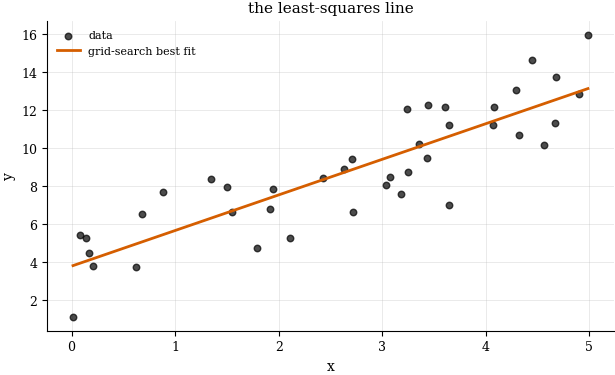

In [6]:
best_w1_i, best_w0_i = imin            # (row, col) into the grid
w0_hat, w1_hat = w0_grid[best_w0_i], w1_grid[best_w1_i]
print(f"grid-search best line:  w0 = {w0_hat:.2f},  w1 = {w1_hat:.2f}   (MSE {J.min():.2f})")
print(f"the true generating line was:  w0 = 3.0,  w1 = 2.0")

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.scatter(x, y, s=22, alpha=0.7, label="data")
ax.plot(xs, predict(xs, w0_hat, w1_hat), color="#D55E00", lw=2, label="grid-search best fit")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("the least-squares line"); ax.legend(fontsize=8)
plt.show()

> ⚠️ **Watch out.** Brute force needs a grid in *every* parameter: with $d$ parameters and $g$
> grid points each, that is $g^{\,d}$ evaluations &mdash; hopeless past two or three. We need the
> minimum **without** scanning everything. That is exactly what the next two notebooks deliver:
> the **normal equations** (02b) jump to the bottom exactly, and **gradient descent** (02c)
> walks there efficiently.

## 6. The compact view: a design matrix

To prepare for many features (and for the linear algebra in 02b), rewrite the model with
vectors. Stack a column of ones (for the intercept) next to the feature column to form the
**design matrix** $\mathbf{X}$, and collect the parameters into $\boldsymbol\theta$:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix},\qquad
\boldsymbol\theta = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix},\qquad
\hat{\mathbf{y}} = \mathbf{X}\,\boldsymbol\theta.$$

Now predictions are a single matrix-vector product, and the cost is
$J(\boldsymbol\theta) = \tfrac1n\lVert \mathbf{X}\boldsymbol\theta - \mathbf{y}\rVert^2$.

In [7]:
X = np.column_stack([np.ones_like(x), x])     # shape (n, 2): [1, x]
theta = np.array([3.0, 2.0])                  # [w0, w1]

yhat_matrix = X @ theta                        # vectorized predictions
yhat_loop   = 3.0 + 2.0 * x
print("design matrix X shape:", X.shape)
print("matrix form matches the scalar form:", np.allclose(yhat_matrix, yhat_loop))

def cost_vec(X, y, theta):
    resid = X @ theta - y
    return np.mean(resid ** 2)

print("vectorized cost equals the earlier cost:",
      np.isclose(cost_vec(X, y, theta), cost(x, y, 3.0, 2.0)))

design matrix X shape: (40, 2)
matrix form matches the scalar form: True
vectorized cost equals the earlier cost: True


> 🔬 **Going deeper.** The design-matrix form is the whole point of the "linear" in linear
> regression: adding features (more columns of $\mathbf{X}$) or transformed features (like $x^2$,
> in 02d) changes *nothing* about the machinery &mdash; predictions stay $\mathbf{X}\boldsymbol\theta$
> and the cost stays a convex bowl in $\boldsymbol\theta$. Everything from here on is written in
> this form.

## Recap & exercises

**Recap.**
* The **model** is a line $\hat y = w_0 + w_1 x$ with two parameters (intercept, slope).
* A **residual** $r_i = y_i - \hat y_i$ measures one prediction's error; summing residuals is
  useless (signs cancel), so we **square** them.
* The **least-squares cost** is the mean squared error $J(w_0,w_1)$; fitting = minimizing it.
* As a function of the parameters, $J$ is a convex **bowl** with one minimum &mdash; the best-fit line.
* In **design-matrix** form, $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol\theta$ and
  $J = \tfrac1n\lVert\mathbf{X}\boldsymbol\theta - \mathbf{y}\rVert^2$; this scales to many features.

**Exercises.**
1. Change the noise: `make_regression_1d(noise=4.0)`. Does the bowl get shallower or steeper near
   its minimum? What does that say about how sharply the data pin down the best line?
2. Add the **mean absolute error** `np.mean(np.abs(resid))` next to the MSE. Re-rank the three
   candidate lines with each &mdash; do they agree?
3. Refine the grid in Section&nbsp;5 (e.g. 400&times;400). How much closer does the grid-search
   line get to $w_0=3, w_1=2$, and how many more cost evaluations did that cost?
4. Plot a **1-D slice** of the bowl: fix $w_1=2$ and plot $J$ vs $w_0$. Is it a parabola? Why?
5. Standardize `x` to mean 0, std 1 and rebuild the contour plot. Does the bowl become more
   circular? (A preview of feature scaling in 02c.)

*Next:* **02b &mdash; the normal equations**: jump straight to the bottom of the bowl with a formula,
and see the beautiful geometry (projection onto the column space) behind it.